In [1]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
import os 
import sys
from torch.utils.data import Dataset, DataLoader
import json
import pickle
import numpy as np 
from tqdm import tqdm 
from bidict import bidict

In [3]:
!pip install bidict

In [5]:
data_path = '/scratch/bczf/zoezheng126/uouo/github-repo/UOUO/keyword/ShareGPT4V'
if data_path not in sys.path:
    sys.path.append(data_path)

os.environ['PYTHONPATH'] = os.environ.get('PYTHONPATH', '') + f":{data_path}"
os.environ['HF_HOME'] = '/scratch/bczf/zoezheng126/huggingface_cache'
os.environ['PATH'] = '/sw/spack/deltas11-2023-03/apps/linux-rhel8-zen3/gcc-11.4.0/cuda-12.3.0-okhhaic/bin:' + os.environ['PATH']

In [9]:
# !pip install einops

  Using cached einops-0.8.0-py3-none-any.whl.metadata (12 kB)
Using cached einops-0.8.0-py3-none-any.whl (43 kB)


## Calculate keywords and hashtags embeddings

In [ ]:
# need compile session

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [7]:
class TextEmbedder:
    def __init__(self, model_name, task_name_to_instruct=None, max_length=32768, use_instruction=True, requires_tokenizer=False, **kwargs):
        self.valid_params = {key: value for key, value in kwargs.items() if value is not None}
        
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = AutoModel.from_pretrained(model_name, trust_remote_code=True, torch_dtype=torch.float16).to(self.device)
        self.tokenizer = AutoTokenizer.from_pretrained(model_name) if requires_tokenizer else None
        self.max_length = max_length
        self.task_name_to_instruct = task_name_to_instruct if task_name_to_instruct else {}
        self.use_instruction = use_instruction
        self.requires_tokenizer = requires_tokenizer

    def _get_instruction(self, task):
        if self.use_instruction and task in self.task_name_to_instruct:
            return "Instruct: " + self.task_name_to_instruct[task] + "\nQuery: "
        return ""

    def encode(self, texts, task="default", batch_size=1):
        prefix = self._get_instruction(task)
        texts = [prefix + text for text in texts]  # Add instructions if applicable

        if self.requires_tokenizer and self.tokenizer:  # For models like gte-base-en-v1.5
            # Tokenize input texts
            batch_dict = self.tokenizer(texts, max_length=self.max_length, **self.valid_params)
            batch_dict = {key: value.to(self.device) for key, value in batch_dict.items()}  # Move tensors to the correct device

            # Get model outputs
            with torch.no_grad():
                outputs = self.model(**batch_dict)
                embeddings = outputs.last_hidden_state[:, 0]  # Get the embeddings (usually the first token)

            # Normalize the embeddings
            embeddings = F.normalize(embeddings, p=2, dim=1)
            return embeddings
        else:  # For models that don’t require tokenizers explicitly
            if batch_size == 1:
                embeddings = self.model.encode(texts, instruction=prefix, max_length=self.max_length)
            else:
                # Mini-batch
                embeddings = self.model._do_encode(
                    texts, batch_size=batch_size, instruction=prefix, max_length=self.max_length, num_workers=4, return_numpy=True
                )
            return F.normalize(torch.tensor(embeddings), p=2, dim=1)

    def similarity_score(self, query_embeddings, passage_embeddings):
        return (query_embeddings @ passage_embeddings.T) * 100

In [8]:
class TextDataset(Dataset):
    def __init__(self, texts, text_prefix=""):
        self.texts = texts
        self.text_prefix = text_prefix

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {
            "text": self.text_prefix + self.texts[idx],
        }

class TextEmbedderWithLoader:
    def __init__(self, model_name, task_name_to_instruct=None, max_length=32768):
        self.model = AutoModel.from_pretrained(model_name, trust_remote_code=True, torch_dtype=torch.float16).to(device)
        self.max_length = max_length
        self.task_name_to_instruct = task_name_to_instruct if task_name_to_instruct else {}

    def _get_instruction(self, task):
        return "Instruct: " + self.task_name_to_instruct.get(task, "") + "\nQuery: "

    def encode_batch(self, batch, task="default"):
        query_embeddings = self.model.encode(batch["text"], instruction=self._get_instruction(task), max_length=self.max_length)
        return F.normalize(torch.tensor(query_embeddings), p=2, dim=1)

    def similarity_score(self, query_embeddings, passage_embeddings):
        return (query_embeddings @ passage_embeddings.T) * 100

In [9]:
# main

In [10]:
# [example] Initialize Dataset and DataLoader
# queries = [
#     'are judo throws allowed in wrestling?', 
#     'how to become a radiology technician in michigan?'
# ]

# passages = [
#     "Since you're reading this, you are probably someone from a judo background or someone who is just wondering how judo techniques can be applied under wrestling rules. So without further ado, let's get to the question. Are Judo throws allowed in wrestling? Yes, judo throws are allowed in freestyle and folkstyle wrestling. You only need to be careful to follow the slam rules when executing judo throws. In wrestling, a slam is lifting and returning an opponent to the mat with unnecessary force.",
#     "Below are the basic steps to becoming a radiologic technologist in Michigan:Earn a high school diploma. As with most careers in health care, a high school education is the first step to finding entry-level employment. Taking classes in math and science, such as anatomy, biology, chemistry, physiology, and physics, can help prepare students for their college studies and future careers.Earn an associate degree. Entry-level radiologic positions typically require at least an Associate of Applied Science. Before enrolling in one of these degree programs, students should make sure it has been properly accredited by the Joint Review Committee on Education in Radiologic Technology (JRCERT).Get licensed or certified in the state of Michigan."
# ]

In [11]:
llama_keyword_dir = '/scratch/bczf/zoezheng126/uouo/github-repo/UOUO/keyword/ShareGPT4V/output/llama_sharegpt4v_keywords'
llama_keyword_dir = '/scratch/bczf/zoezheng126/uouo/github-repo/UOUO/keyword/mmmu/test_keyword'

txt_files = [f for f in os.listdir(llama_keyword_dir) if f.startswith("llama_keywords_") and f.endswith(".txt")]

txt_files_sorted = sorted(txt_files, key=lambda x: int(x.split('_')[-1].split('.')[0]))

all_keywords_sorted = []

for filename in txt_files_sorted:
    with open(os.path.join(llama_keyword_dir, filename), 'r') as file:
        lines = file.readlines()
        for line in lines:
            kws = line.strip().split(', ')
            kws = kws[:5] if len(kws) > 5 else kws
            all_keywords_sorted.extend(kws)


In [12]:
keyword_dataset = TextDataset(all_keywords_sorted)

# DataLoader for batching
batch_size = 64
keyword_dataloader = DataLoader(keyword_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

# Text Embedder Model
task_name_to_instruct = {
    "example": "Given a question, retrieve passages that answer the question",
}
# embedder = TextEmbedderWithLoader('nvidia/NV-Embed-v2', task_name_to_instruct)
model_name = 'gte-base-en-v1.5'
embedder = TextEmbedder(model_name='Alibaba-NLP/gte-base-en-v1.5', max_length=8192, use_instruction=False, requires_tokenizer=True, padding=True, truncation=True, return_tensors='pt')

/projects/bbyr/zoezheng126/uouo/lib/python3.10/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [25]:
all_query_embeddings = []
all_passage_embeddings = []
os.environ['TOKENIZERS_PARALLELISM']='True'
output_path = '/scratch/bczf/zoezheng126/uouo/github-repo/UOUO/keyword/ShareGPT4V/embeddings'
output_path = '/scratch/bczf/zoezheng126/uouo/github-repo/UOUO/keyword/mmmu/embeddings'
index_dict = dict()
output_embeddings = []
output_text = []
i = 0
for batch in tqdm(keyword_dataloader):
    text = batch['text']
    query_embeddings = embedder.encode(text) #task="example" for nvidia/NV-Embed-v2\
    query_embeddings_list = query_embeddings.to('cpu').tolist()
    output_embeddings.extend(query_embeddings_list)
    output_text.extend(text)
    for j in range(len(text)):
        index_dict[text[j]] = i + j
    i += len(text) + 1

output_all = [index_dict, output_embeddings, output_text]
    
query_embeddings_file = f'{output_path}/single_keyword_embeddings_dict_{model_name}.pkl'
# save embeddings
with open(query_embeddings_file, 'wb') as f:
    pickle.dump(output_all, f)


100%|██████████| 805/805 [00:14<00:00, 55.13it/s]


In [27]:
embeddings = output_embeddings
texts = output_text

In [16]:
import pickle

with open('/scratch/bczf/zoezheng126/uouo/github-repo/UOUO/keyword/mmmu/embeddings/single_keyword_embeddings_dict_gte-base-en-v1.5.pkl', 'rb') as file:
    data = pickle.load(file)

index_dict, embeddings, texts = data


In [17]:
unique_texts_embeddings = dict()
for text, embedding in zip(texts, embeddings):
    if text not in unique_texts_embeddings:
        unique_texts_embeddings[text] = embedding

# Extract the unique texts and embeddings
unique_texts = list(unique_texts_embeddings.keys())
unique_embeddings = list(unique_texts_embeddings.values())

In [18]:
print(len(unique_embeddings))
texts = unique_texts 
embeddings = unique_embeddings

11963


In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
k = 0
for k in range(150, 500, 50):  # Start from 50, go up to 300, in steps of 50
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(embeddings)
    wcss.append(kmeans.inertia_)
    k += 1

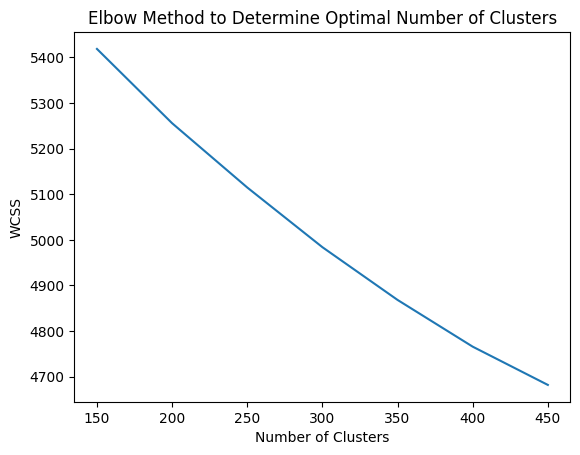

In [43]:
# Plot the Elbow Method graph
plt.plot(range(150, 500, 50), wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method to Determine Optimal Number of Clusters')
plt.show()

In [42]:
wcss[1]

5255.672863469454

In [19]:
from sklearn.cluster import KMeans
num_clusters = 500  # Specify the number of clusters you want
kmeans = KMeans(n_clusters=num_clusters, random_state=0)
kmeans.fit(embeddings)

labels = kmeans.labels_

# Group texts based on their cluster labels
clusters = {i: [] for i in range(num_clusters)}
for text, label in zip(texts, labels):
    clusters[label].append(text)

# Print the texts in each cluster
for cluster_id, cluster_texts in clusters.items():
    print(f"Cluster {cluster_id}:")
    for text in cluster_texts:
        print(f"  {text}")


Cluster 0:
  window
  frame
  grid
  panel
  panels
  Panel
  screen
  Window
Cluster 1:
  par
  RHS
  sp
  PVY
  ABA
  CI
  anallactic
  CA
  AB
  EI
  aadt
  FRA
  Niepce
  Las
  ISO
  Fra
  Ingres
  Kufic
  conus
  Nissl
  conformer
  Cl
  CO
  ESR
  para
  Ni
  cis
  Cr
  CEA
  FVC
  AST
  AD-AS
  testscri
  AS
  LRAS
  SRAS
  vars
  psia
  psi
  Pa
  Pret
  MO
  fir
  4140
  SC
  Ax
  semi
  Ab
  FA tests
  STP
  Co
  CF
  Asch
  BSI
  PAR
  CL
  RR
  H MRS
Cluster 2:
  activities
  humans
  persons
  contemporary
  people
  Back
  living
  trend
  individuals
  behavior
  individual
  occurring
  behavioral
  person
  back
  situations
  Demographic
  self
  demographic
  lifestyle
  trends
  First person
  Situations
  activity-based
  participants
  interview
  Interview
  contexts
  human behavior
  participant
  People
  behaviors
  behaviour
  Living
Cluster 3:
  loaded
  collateral
  hologous
  monopoly
  infinite
  payback
  Payback
  fractured
  cartel
  roulette
  greedy